# PR6 · Measuring Tail Risk: Value at Risk and Stress Testing

Volatility describes a typical day. Risk managers care most about the bad days. This notebook measures them in two complementary ways: statistically (Value at Risk and Expected Shortfall) and with scenarios (stress tests).

## 1. Motivation

The club's investment committee asks one question: "How much could we lose?" Saying "volatility is 10%" doesn't answer it. They want something like "on 99 days out of 100, we shouldn't lose more than X", plus "if 2020 happened again tomorrow, we would lose Y". Banks are legally required to report numbers like these every day. They are also the numbers most likely to be wrong at the worst possible moment.

## 2. Intuition

- **Value at Risk (VaR)** is a threshold: "on 99% of days, the loss will be smaller than this." It says nothing about how bad the other 1% can get.
- **Expected Shortfall (ES)** answers that follow-up question: "*when* we do have one of those worst 1% days, how much do we lose on average?"
- **Stress testing** forgets probabilities and asks "what if?": what would this portfolio lose if a specific historical crisis, or a made-up but plausible shock, happened today?

VaR and ES rely on history repeating itself statistically. Stress tests let you imagine events that are rare or have never happened. A good risk report uses both.

## 3. The math

Let $R$ be the portfolio's daily return and $\alpha$ a small probability, e.g. 1%. Losses are reported as positive numbers.

**Value at Risk:**
$$
\text{VaR}_\alpha = -q_\alpha(R), \qquad \text{where } \Pr\big(R \le q_\alpha\big) = \alpha .
$$

**Expected Shortfall:**
$$
\text{ES}_\alpha = -\mathbb{E}\big[R \mid R \le q_\alpha\big] \;\ge\; \text{VaR}_\alpha .
$$

Three ways to estimate $q_\alpha$:

1. **Historical:** the $\alpha$-quantile of past returns (e.g. the 3rd-worst day out of the last 250).
2. **Parametric (normal):** assume $R \sim \mathcal N(\mu, \sigma^2)$, so $q_\alpha = \mu + z_\alpha\sigma$ with $z_{0.01} \approx -2.33$.
3. **Monte Carlo:** simulate many returns from a fitted model and take their quantile. (Not covered here; it is method 2 with a more flexible model.)

**Backtesting VaR.** If the model is right, the number of days where the loss exceeds VaR (**exceptions**) over $n$ days follows a Binomial($n$, $\alpha$) distribution. With $n = 250$ and $\alpha = 1\%$ we expect about 2.5 exceptions a year. Far more than that means the model underestimates risk.

**Stress test.** For a scenario where asset $i$ returns $\Delta_i$, the portfolio return is simply $\sum_i w_i \Delta_i$.

## 4. Code it

### 4.1 Setup: a multi-asset portfolio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

weights = pd.Series({"SPY": 0.50, "IEF": 0.30, "GLD": 0.10, "VNQ": 0.10})
asset_ret = prices[weights.index].pct_change().dropna()
port = asset_ret @ weights               # daily portfolio return, rebalanced daily
print(f"Portfolio volatility: {port.std() * np.sqrt(252):.1%} per year")

Portfolio volatility: 10.3% per year


### 4.2 VaR and ES over the whole sample

Historical 99% VaR: 1.74%   ES: 2.59%
Normal     99% VaR: 1.46%   ES: 1.68%
Worst day in sample: 6.57%  (2020-03-16)


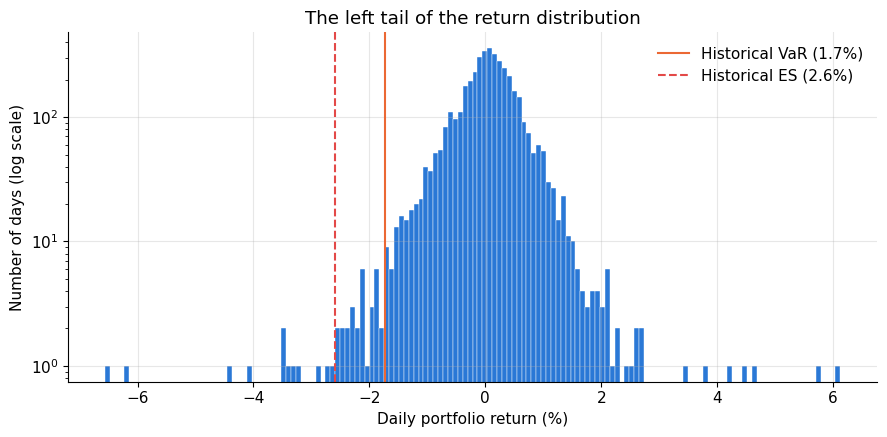

In [2]:
alpha = 0.01
q = port.quantile(alpha)                                     # historical q_alpha
hist_var = -q
hist_es = -port[port <= q].mean()                            # average of the worst 1% of days
param_var = -(port.mean() + norm.ppf(alpha) * port.std())    # -(mu + z_alpha sigma)
param_es = -(port.mean() - port.std() * norm.pdf(norm.ppf(alpha)) / alpha)   # normal-distribution ES

print(f"Historical 99% VaR: {hist_var:.2%}   ES: {hist_es:.2%}")
print(f"Normal     99% VaR: {param_var:.2%}   ES: {param_es:.2%}")
print(f"Worst day in sample: {-port.min():.2%}  ({port.idxmin().date()})")

fig, ax = plt.subplots()
ax.hist(port * 100, bins=150, color=COLORS[0], edgecolor="white", linewidth=0.3)
ax.axvline(-hist_var * 100, color=COLORS[1], label=f"Historical VaR ({hist_var:.1%})")
ax.axvline(-hist_es * 100, color=COLORS[7], ls="--", label=f"Historical ES ({hist_es:.1%})")
ax.set_yscale("log")
ax.set_xlabel("Daily portfolio return (%)")
ax.set_ylabel("Number of days (log scale)")
ax.set_title("The left tail of the return distribution")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

- **Historical:** on 1% of days the portfolio lost more than about 1.7%. On those days the average loss was about 2.6% (ES).
- **The normal model understates both**, and ES much more than VaR (1.7% vs 2.6%). The normal distribution has thin tails, so it badly underestimates how bad the worst days are.
- **The worst day (−6.6%, 16 March 2020) was almost four times the historical VaR.** VaR says where the tail starts, not how far it goes. The log-scale histogram shows the long left tail.

### 4.3 Backtesting a rolling VaR

In practice VaR is re-estimated every day from a recent window, then compared with the next day's actual return. We use the last 250 days.

In [3]:
window = 250
var_hist = -port.rolling(window).quantile(alpha).shift(1)        # uses data up to yesterday only
mu_r = port.rolling(window).mean().shift(1)
sd_r = port.rolling(window).std().shift(1)
var_norm = -(mu_r + norm.ppf(alpha) * sd_r)

test = pd.DataFrame({"ret": port, "Historical": var_hist, "Normal": var_norm}).dropna()
n = len(test)
expected = alpha * n
for model in ["Historical", "Normal"]:
    exceptions = (test["ret"] < -test[model]).sum()                # days where loss > VaR
    p_value = 1 - binom.cdf(exceptions - 1, n, alpha)              # P(at least this many | model right)
    print(f"{model:>10}: {exceptions} exceptions vs {expected:.0f} expected  (p-value {p_value:.4f})")

Historical: 54 exceptions vs 40 expected  (p-value 0.0165)
    Normal: 89 exceptions vs 40 expected  (p-value 0.0000)


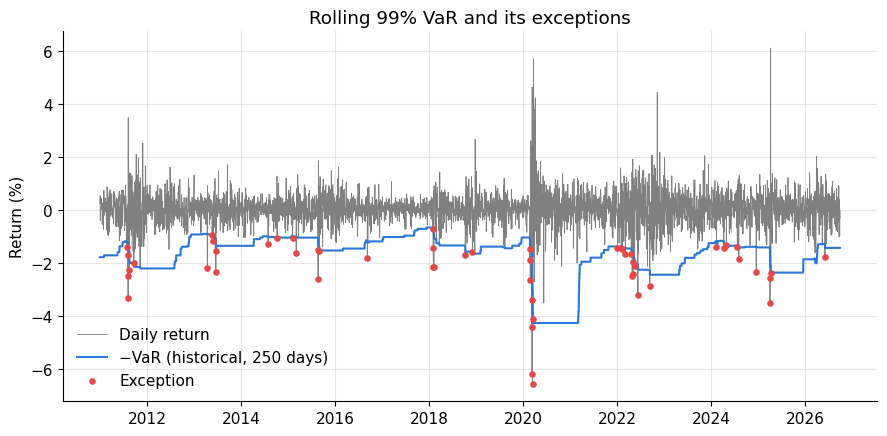

Exceptions per year: {2010: 0, 2011: 6, 2012: 0, 2013: 5, 2014: 2, 2015: 5, 2016: 1, 2017: 0, 2018: 6, 2019: 0, 2020: 8, 2021: 0, 2022: 11, 2023: 0, 2024: 6, 2025: 3, 2026: 1}


In [4]:
fig, ax = plt.subplots()
ax.plot(test.index, test["ret"] * 100, color="grey", linewidth=0.6, label="Daily return")
ax.plot(test.index, -test["Historical"] * 100, color=COLORS[0], label="−VaR (historical, 250 days)")
hits = test[test["ret"] < -test["Historical"]]
ax.scatter(hits.index, hits["ret"] * 100, color=COLORS[7], s=14, zorder=3, label="Exception")
ax.set_ylabel("Return (%)")
ax.set_title("Rolling 99% VaR and its exceptions")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

per_year = hits.groupby(hits.index.year).size().reindex(range(test.index[0].year, test.index[-1].year + 1), fill_value=0)
print("Exceptions per year:", per_year.to_dict())

Both models fail the backtest. They break more often than a correct 1% VaR would (the p-values are below 5%), and the normal model fails badly, with more than twice the expected number of exceptions.

The plot shows *why*. Exceptions come in **clusters**: 8 in 2020 and 11 in 2022, but none in calm years such as 2017, 2019 and 2023. A 250-day window still remembers last year's calm when a crisis starts. VaR is lowest exactly when risk is about to jump, then it stays high for a year after the crisis (note the long plateau after 2020). Models that weight recent days more heavily react faster, but no historical model sees a crisis coming.

### 4.4 Historical stress tests

Now the scenario view. We apply the *cumulative* return of each asset during past crises to today's weights.

In [5]:
scenarios = {
    "2011 US downgrade (Jul 22 – Aug 8)": ("2011-07-22", "2011-08-08"),
    "2018 Q4 sell-off (Sep 20 – Dec 24)": ("2018-09-20", "2018-12-24"),
    "2020 COVID crash (Feb 19 – Mar 23)": ("2020-02-19", "2020-03-23"),
    "2022 inflation shock (Jan 3 – Oct 12)": ("2022-01-03", "2022-10-12"),
}
rows = {}
for name, (start, end) in scenarios.items():
    shock = prices.loc[end, weights.index] / prices.loc[start, weights.index] - 1   # Delta_i per asset
    rows[name] = {**shock.to_dict(), "Portfolio": shock @ weights}                   # sum_i w_i Delta_i
stress = pd.DataFrame(rows).T
stress.map("{:+.1%}".format)

,SPY,IEF,GLD,VNQ,Portfolio
2011 US downgrade (Jul 22 – Aug 8),-16.6%,+4.5%,+7.0%,-22.6%,-8.5%
2018 Q4 sell-off (Sep 20 – Dec 24),-19.3%,+3.4%,+5.0%,-11.1%,-9.3%
2020 COVID crash (Feb 19 – Mar 23),-33.7%,+6.4%,-3.6%,-41.5%,-19.5%
2022 inflation shock (Jan 3 – Oct 12),-24.5%,-15.4%,-7.3%,-31.9%,-20.8%


- **COVID 2020** was the fastest crash. Stocks and real estate collapsed, but Treasuries rose (+6%) and cushioned the portfolio. The portfolio lost about 20%.
- **2022** was the worst scenario for this portfolio, even though stocks fell *less* than in 2020. Every asset fell together: bonds −15%, gold −7%. Diversification failed, as notebook 3's rolling correlation predicted.
- A one-day 99% VaR of 1.7% says nothing about losses like these, which build up over weeks or months.

### 4.5 A hypothetical scenario

History doesn't contain every possible crisis. A hypothetical scenario combines shocks that are economically plausible together. Here: stagflation, where stocks fall 25%, interest rates rise 2 percentage points, and gold rallies.

For a bond, the price change from a rate move is about $-D \times \Delta y$, where the **duration** $D$ is roughly the average time until the bond's cash flows arrive, in years. IEF holds 7–10 year Treasuries, with duration of about 7.5.

In [6]:
duration_ief = 7.5
hypothetical = pd.Series({
    "SPY": -0.25,                      # equity crash
    "IEF": -duration_ief * 0.02,       # rates +2pp -> about -15%
    "GLD": +0.10,                      # flight to real assets
    "VNQ": -0.30,                      # real estate is hit by both falling stocks and rising rates
})
print("Shocks:", hypothetical.map("{:+.0%}".format).to_dict())
print(f"Portfolio loss: {hypothetical @ weights:+.1%}")
print(f"For comparison, 99% one-day historical VaR: -{hist_var:.1%}")

Shocks: {'SPY': '-25%', 'IEF': '-15%', 'GLD': '+10%', 'VNQ': '-30%'}
Portfolio loss: -19.0%
For comparison, 99% one-day historical VaR: -1.7%


The stagflation scenario loses about 19%, close to the worst historical episodes, even though the gold rally helps. Note what drives the loss: the 30% in bonds, which is supposed to be the safe part, contributes −4.5 percentage points. Writing scenarios like this forces you to ask *which assumptions about correlations* the portfolio relies on.

## 5. Takeaways and where it breaks

- **VaR is a threshold, ES is the average beyond it.** Report both. ES is the better guide to how bad a bad day is.
- **The normal distribution underestimates tails.** Historical VaR, or models with fat tails, are safer defaults.
- **A rolling VaR adapts with a lag.** It is too low just before a crisis and too high just after. Exceptions come in clusters.
- **Stress tests cover what statistics can't:** regime changes (2022) and events that aren't in the data window.
- **Where it breaks:** VaR is not *subadditive*: the VaR of a combined portfolio can exceed the sum of the parts' VaRs, which makes it awkward to allocate risk across desks. ES doesn't have this problem, which is one reason regulators moved towards it. Hypothetical scenarios are only as good as the imagination (and honesty) of whoever writes them.

**What you could build:** a weekly risk report for the club portfolio: rolling VaR and ES, the exception count, and a standard set of historical and hypothetical stress scenarios.